<a href="https://colab.research.google.com/github/JanieliSilva/Redes_neurais/blob/main/aprendizagem_supervisionada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
entrada = df.drop('quality', axis=1)
saida_desejada = df['quality'].values

entrada_treino, entrada_teste, saida_desejada_treino, saida_desejada_teste = train_test_split(entrada, saida_desejada, test_size=0.2)

In [10]:
scaler = StandardScaler()
entrada_treino_padronizados = scaler.fit_transform(entrada_treino)
entrada_teste_padronizados = scaler.transform(entrada_teste)

In [66]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=32, activation='relu', input_shape=(entrada_treino_padronizados.shape[1],)))
model.add(tf.keras.layers.Dense(units=8, activation='relu'))
model.add(tf.keras.layers.Dense(units=1))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657 (2.57 KB)

 Trainable params: 657 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(optimizer='adam', loss='mse')

In [68]:
history = model.fit(entrada_treino_padronizados, saida_desejada_treino, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 29.3911 - val_loss: 26.0332
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.0424 - val_loss: 17.1981
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 12.6110 - val_loss: 7.7827
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5866 - val_loss: 3.7728
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3998 - val_loss: 2.9635
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.7543 - val_loss: 2.4793
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.3655 - val_loss: 2.1343
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.0930 - val_loss: 1.9336
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.8956 - val_loss: 1.7754
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7468 - val_loss: 1.6420
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6217 - val_loss: 1.5444
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

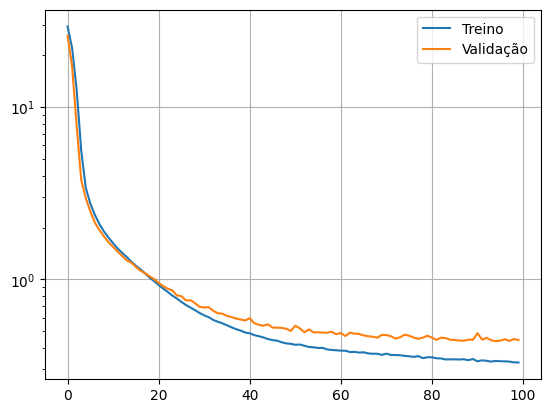

In [69]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

In [70]:
saida_predita = model.predict(entrada_teste_padronizados)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [72]:
print('MSE:', mean_squared_error(saida_desejada_teste, saida_predita))

MSE: 0.43811923265457153


In [73]:
saida_predita = saida_predita.reshape(saida_predita.shape[0])

print('R2', r2_score(saida_desejada_teste, saida_predita))

R2 0.31258565187454224


In [74]:
dados_de_entrada = np.array([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 32.4, 3.4, 11.0]])

dados_de_entrada_padro = scaler.transform(dados_de_entrada)

predicted_quality = model.predict(dados_de_entrada_padro)

print('Qualidade prevista:', predicted_quality[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Qualidade prevista: 12.141154
